In [54]:
#라이브러리 불러오기
import time
import joblib
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay,
)

In [55]:
#테스트 데이터와 모델 데이터 불러오기
test_data = joblib.load("test_data.pkl")

X_test = test_data["X_test"]
y_test = test_data["y_test"]

decision_tree_model = joblib.load(
    "decision_tree_model.pkl"
)

logistic_model = joblib.load(
    "logistic_model.pkl"
)

random_forest_model = joblib.load(
    "risk_model.pkl"
)

print("테스트 데이터 크기:", X_test.shape)

print("\n테스트 데이터 클래스 분포")
print(pd.Series(y_test).value_counts().sort_index())

테스트 데이터 크기: (1999, 668)

테스트 데이터 클래스 분포
0    239
1    871
2     69
3    820
Name: count, dtype: int64


In [56]:
#모델 평가 함수
def evaluate_model(
    model,
    X_test,
    y_test,
    model_name,
):
    """모델의 분류 성능과 예측 시간을 평가한다."""

    start_time = time.perf_counter()

    prediction = model.predict(X_test)

    prediction_time = (
        time.perf_counter() - start_time
    )

    accuracy = accuracy_score(
        y_test,
        prediction
    )

    precision = precision_score(
        y_test,
        prediction,
        average="weighted",
        zero_division=0,
    )

    recall = recall_score(
        y_test,
        prediction,
        average="weighted",
        zero_division=0,
    )

    weighted_f1 = f1_score(
        y_test,
        prediction,
        average="weighted",
        zero_division=0,
    )

    macro_f1 = f1_score(
        y_test,
        prediction,
        average="macro",
        zero_division=0,
    )

    print("=" * 50)
    print(model_name)
    print("=" * 50)

    print(f"Accuracy          : {accuracy:.4f}")
    print(f"Weighted Precision: {precision:.4f}")
    print(f"Weighted Recall   : {recall:.4f}")
    print(f"Weighted F1-score : {weighted_f1:.4f}")
    print(f"Macro F1-score    : {macro_f1:.4f}")
    print(f"Prediction Time   : {prediction_time:.4f}초")

    print("\n클래스별 성능")
    print(
        classification_report(
            y_test,
            prediction,
            zero_division=0,
        )
    )

    return {
        "model": model_name,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "weighted_f1": weighted_f1,
        "macro_f1": macro_f1,
        "prediction_time": prediction_time,
        "prediction": prediction,
    }

In [57]:
#세 가지의 모델 평가
dt_result = evaluate_model(
    decision_tree_model,
    X_test,
    y_test,
    "Decision Tree",
)

lr_result = evaluate_model(
    logistic_model,
    X_test,
    y_test,
    "Logistic Regression",
)

rf_result = evaluate_model(
    random_forest_model,
    X_test,
    y_test,
    "Random Forest",
)

Decision Tree
Accuracy          : 0.6948
Weighted Precision: 0.6872
Weighted Recall   : 0.6948
Weighted F1-score : 0.6880
Macro F1-score    : 0.5624
Prediction Time   : 0.0020초

클래스별 성능
              precision    recall  f1-score   support

           0       0.66      0.59      0.62       239
           1       0.71      0.70      0.71       871
           2       0.38      0.13      0.19        69
           3       0.70      0.77      0.73       820

    accuracy                           0.69      1999
   macro avg       0.61      0.55      0.56      1999
weighted avg       0.69      0.69      0.69      1999

Logistic Regression
Accuracy          : 0.7034
Weighted Precision: 0.6997
Weighted Recall   : 0.7034
Weighted F1-score : 0.6953
Macro F1-score    : 0.5643
Prediction Time   : 0.0009초

클래스별 성능
              precision    recall  f1-score   support

           0       0.64      0.69      0.66       239
           1       0.73      0.71      0.72       871
           2       0.55 

In [ ]:
dt_result = evaluate_model(
    decision_tree_model,
    X_test,
    y_test,
    "Decision Tree",
)

# Decision Tree : 단일 트리 기반 모델로 학습을 수행하고 성능을 평가함.

Decision Tree
Accuracy          : 0.6948
Weighted Precision: 0.6872
Weighted Recall   : 0.6948
Weighted F1-score : 0.6880
Macro F1-score    : 0.5624
Prediction Time   : 0.0020초

클래스별 성능
              precision    recall  f1-score   support

           0       0.66      0.59      0.62       239
           1       0.71      0.70      0.71       871
           2       0.38      0.13      0.19        69
           3       0.70      0.77      0.73       820

    accuracy                           0.69      1999
   macro avg       0.61      0.55      0.56      1999
weighted avg       0.69      0.69      0.69      1999



In [ ]:
lr_result = evaluate_model(
    logistic_model,
    X_test,
    y_test,
    "Logistic Regression",
)
# Logistic Regression : 선형 분류 모델로 학습을 수행하여 다른 모델과 성능을 비교함.

Logistic Regression
Accuracy          : 0.7034
Weighted Precision: 0.6997
Weighted Recall   : 0.7034
Weighted F1-score : 0.6953
Macro F1-score    : 0.5643
Prediction Time   : 0.0016초

클래스별 성능
              precision    recall  f1-score   support

           0       0.64      0.69      0.66       239
           1       0.73      0.71      0.72       871
           2       0.55      0.09      0.15        69
           3       0.70      0.75      0.73       820

    accuracy                           0.70      1999
   macro avg       0.65      0.56      0.56      1999
weighted avg       0.70      0.70      0.70      1999



In [ ]:
rf_result = evaluate_model(
    random_forest_model,
    X_test,
    y_test,
    "Random Forest",
)
# Random Forest : 앙상블(여러 개 ML 모델들 결합하여 하나의 강력한 모델 만드는 방법) 기법을 적용한 모델로, 비교 결과 Accuracy가 가장 높아 최종 모델로 선정함.

Random Forest
Accuracy          : 0.7199
Weighted Precision: 0.7057
Weighted Recall   : 0.7199
Weighted F1-score : 0.7025
Macro F1-score    : 0.5227
Prediction Time   : 0.0854초

클래스별 성능
              precision    recall  f1-score   support

           0       0.89      0.45      0.60       239
           1       0.71      0.76      0.73       871
           2       0.00      0.00      0.00        69
           3       0.71      0.82      0.76       820

    accuracy                           0.72      1999
   macro avg       0.58      0.51      0.52      1999
weighted avg       0.71      0.72      0.70      1999



# Confusion Matrix : 실제 위험도와 예측 위험도를 비교하여 모델의 정분류 및 오분류 현황을 확인한다.

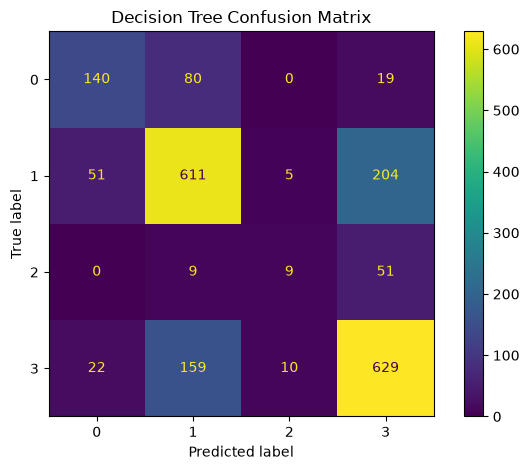

In [ ]:
# Decision Tree 혼동행렬 출력
ConfusionMatrixDisplay.from_predictions(
    y_test,
    dt_result["prediction"],
)

plt.title("Decision Tree Confusion Matrix")
plt.tight_layout()
plt.show()

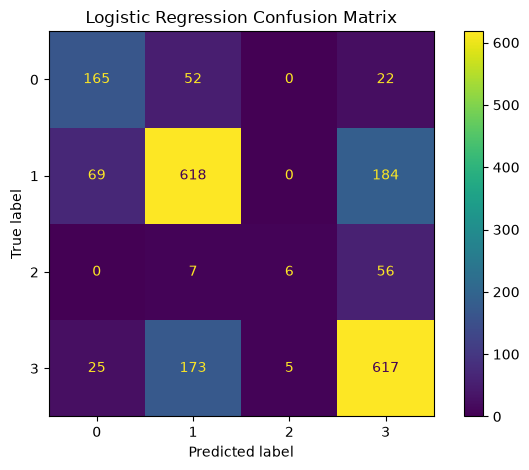

In [ ]:
# Logistic Regression 혼동행렬 출력
ConfusionMatrixDisplay.from_predictions(
    y_test,
    lr_result["prediction"],
)

plt.title("Logistic Regression Confusion Matrix")
plt.tight_layout()
plt.show()

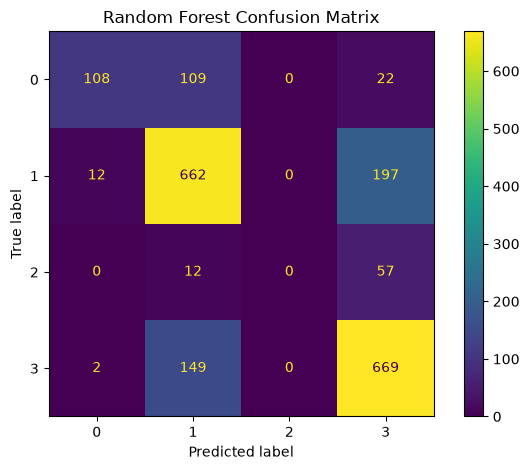

In [ ]:
# Random Forest 혼동행렬 출력
ConfusionMatrixDisplay.from_predictions(
    y_test,
    rf_result["prediction"],
)

plt.title("Random Forest Confusion Matrix")
plt.tight_layout()
plt.show()

In [ ]:
# 평가 결과 정리
evaluation_result = pd.DataFrame(
    [
        {
            key: value
            for key, value in dt_result.items()
            if key != "prediction"
        },
        {
            key: value
            for key, value in lr_result.items()
            if key != "prediction"
        },
        {
            key: value
            for key, value in rf_result.items()
            if key != "prediction"
        },
    ]
)

display(evaluation_result)

,model,accuracy,precision,recall,weighted_f1,macro_f1,prediction_time
0,Decision Tree,0.694847,0.687186,0.694847,0.688017,0.562374,0.002040
1,Logistic Regression,0.703352,0.699724,0.703352,0.695267,0.564287,0.001551
2,Random Forest,0.719860,0.705730,0.719860,0.702464,0.522686,0.085369


In [ ]:
# 최종 모델 선정
best_model_row = evaluation_result.loc[
    evaluation_result["accuracy"].idxmax()
]

print("=" * 50)
print("최종 모델 선정 결과")
print("=" * 50)

print("선정 모델:", best_model_row["model"])
print(
    "Accuracy:",
    round(best_model_row["accuracy"], 4)
)
print(
    "Weighted F1-score:",
    round(best_model_row["weighted_f1"], 4)
)
print(
    "Macro F1-score:",
    round(best_model_row["macro_f1"], 4)
)

최종 모델 선정 결과
선정 모델: Random Forest
Accuracy: 0.7199
Weighted F1-score: 0.7025
Macro F1-score: 0.5227


In [ ]:
# 모델 예측 결과 비교
dt_pred = decision_tree_model.predict(X_test)
rf_pred = random_forest_model.predict(X_test)

print("예측이 다른 개수:", (dt_pred != rf_pred).sum())

예측이 다른 개수: 385


<핵심 과정>
1. 저장된 모델 불러오기
2. Accuracy, F1-score 평가
3. Confusion Matrix 출력
4. 모델 성능 비교
5. 최종 모델 선정

<결과>
=> 프로젝트의 목적이 취약점 위험도를 최대한 정확하게 예측하는 것이므로, 전체 예측 정확도를 가장 직관적으로 평가가 가능한 Accuracy를 최종 모델 선정 기준으로 사용하였음. 이를 비교한 결과 Random Forest가 가장 높은 성능을 보여 최종 모델로 선정하게 되었음!

<부연설명>
Severity는 CVSS Score를 기준으로 LOW(0.1~3.9), MEDIUM(4.0~6.9), HIGH(7.0~8.9), CRITICAL(9.0~10.0) 등으로 구분하였다. 하지만 이는 점수 구간만 나눈 것일 뿐, 각 구간의 데이터 개수가 동일하다는 의미는 아니기에 실제 데이터 분포를 확인한 결과,

HIGH : 43.52%
MEDIUM : 41.01%
CRITICAL : 11.94%
LOW : 3.47%
NONE : 0.06%

로 나타나 HIGH와 MEDIUM이 전체 데이터의 약 85%를 차지하는 반면, LOW와 NONE은 매우 적은 비율을 차지하는 클래스 불균형(Class Imbalance) 이 존재하였다.

Accuracy는 전체 데이터 중 올바르게 예측한 비율을 평가하는 지표인 반면, Macro F1-score는 모든 클래스를 동일한 비중으로 평가한다. 따라서 데이터가 적은 LOW와 NONE 클래스의 예측 성능이 낮을 경우 Macro F1-score는 상대적으로 크게 감소하게 된다.

본 프로젝트의 목적은 취약점 위험도를 전체적으로 정확하게 예측하여 우선순위를 제시하는 것이므로, 전체 예측 성능을 가장 직관적으로 나타낼 수 있는 Accuracy를 최종 모델 선정 기준으로 적용하였다. Macro F1-score는 참고 지표로 함께 확인하였으며, 클래스 불균형의 영향으로 Accuracy보다 낮게 측정되었다.